Reduce features so better visualisation and computation
<br><br>
ABout feature selection, go with the one jispr zyada varuance zyada spread like number of rooms vs grocery shops <br>


covariance and corelation are the same but corelation is between-1 to 1 and corelation has no restriction

geogebra website is cool

covariance matrix tells spread across each feature, also relations

matrixes make changes in our co-ordinate system

eigen vector gets its magnitude changed but never direction, in every transformation you can two of these 

biggest eigen vector, biggest correlation

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

np.random.seed(23)

# class 1
mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])

class1_sample = np.random.multivariate_normal(
    mu_vec1,
    cov_mat1,
    20
)

df = pd.DataFrame(
    class1_sample,
    columns=['feature1','feature2','feature3']
)

df['target'] = 1

# class 2
mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])

class2_sample = np.random.multivariate_normal(
    mu_vec2,
    cov_mat2,
    20
)

df1 = pd.DataFrame(
    class2_sample,
    columns=['feature1','feature2','feature3']
)

df1['target'] = 0

# combine
df = pd.concat([df, df1], ignore_index=True)

# shuffle
df = df.sample(40)

# plot
fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='feature3',
    color=df['target'].astype(str)
)

fig.update_traces(
    marker=dict(
        size=12,
        line=dict(
            width=2,
            color='DarkSlateGrey'
        )
    )
)

fig.show()

AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [3]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [4]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [5]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[ 1.05263158  0.20397591 -0.28888004]
 [ 0.20397591  1.05263158  0.10956124]
 [-0.28888004  0.10956124  1.05263158]]


In [6]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [8]:
eigen_values

array([0.64212617, 1.36120658, 1.15456198])

In [9]:
eigen_vectors

array([[-0.65172443,  0.74834128,  0.12345283],
       [ 0.48046517,  0.28140349,  0.8306415 ],
       [-0.58686326, -0.60066414,  0.54294945]])

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


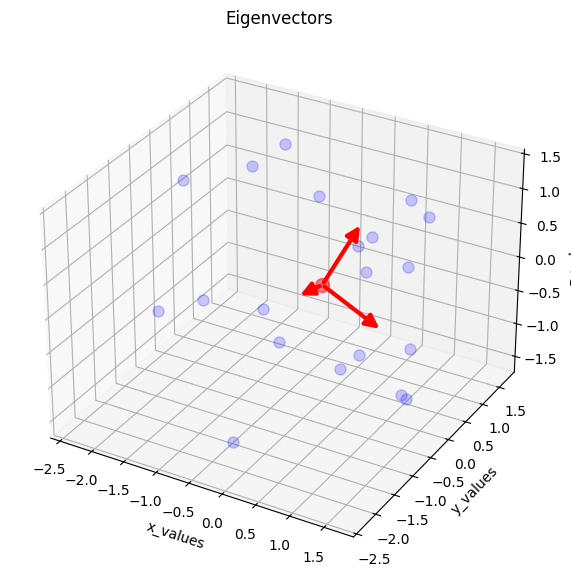

In [15]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)
    
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
for v in eigen_vectors.T:
    a = Arrow3D([df['feature1'].mean(), v[0]], [df['feature2'].mean(), v[1]], [df['feature3'].mean(), v[2]], mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

In [16]:
pc = eigen_vectors[0:2]
pc

array([[-0.65172443,  0.74834128,  0.12345283],
       [ 0.48046517,  0.28140349,  0.8306415 ]])

In [17]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,-0.304909,-0.545559,1
1,0.238477,-0.429512,1
2,-1.078773,-2.044435,1
3,-1.135779,1.289053,1
4,-0.107685,-0.957342,1


In [13]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

PCA code Kaggle notebook : https://www.kaggle.com/nitsin/pca-demo-1 Video Link:https://youtu.be/tXXnxjj2wM4

In [ ]:
eigen_vectors

array([[-0.65172443,  0.74834128,  0.12345283],
       [ 0.48046517,  0.28140349,  0.8306415 ],
       [-0.58686326, -0.60066414,  0.54294945]])

pca doesn't work when vairnace is spread on x and y like eigen se change nii hoga, where upr wala projection is niche and left wala porjection is on right 